In [2]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Define date range
start_date = '2015-01-01'
end_date = '2026-06-30'

# Define assets
assets = {
    'TSLA': 'Tesla Inc.',
    'BND': 'Vanguard Total Bond Market ETF',
    'SPY': 'S&P 500 ETF'
}

# Download data
def fetch_stock_data(tickers, start, end):
    """Fetch historical data for given tickers"""
    data = {}
    for ticker in tickers:
        print(f"Fetching data for {ticker}...")
        try:
            stock = yf.download(ticker, start=start, end=end, progress=False)
            data[ticker] = stock
        except Exception as e:
            print(f"Error fetching {ticker}: {e}")
    return data

# Download data
stock_data = fetch_stock_data(assets.keys(), start_date, end_date)

# Create combined DataFrame
def create_combined_df(data_dict):
    """Create a combined DataFrame with MultiIndex columns"""
    combined = pd.concat(data_dict, axis=1)
    return combined

# Create combined DataFrame
combined_data = create_combined_df(stock_data)

# Display basic info
print("Combined Data Shape:", combined_data.shape)
print("\nFirst 5 rows:")
print(combined_data.head())
print("\nLast 5 rows:")
print(combined_data.tail())

# Extract closing prices for analysis
close_prices = combined_data.xs('Close', level=1, axis=1)
close_prices.columns = [col[0] for col in close_prices.columns]

print("\nClosing Prices Shape:", close_prices.shape)
print(close_prices.head())

Matplotlib is building the font cache; this may take a moment.


Fetching data for TSLA...


$TSLA: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-06-30)

1 Failed download:
['TSLA']: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-06-30)


Fetching data for BND...
Fetching data for SPY...
Combined Data Shape: (2888, 16)

First 5 rows:
                TSLA                                    BND             \
Price      Adj Close Close High  Low Open Volume      Close       High   
Ticker          TSLA  TSLA TSLA TSLA TSLA   TSLA        BND        BND   
2015-01-02       NaN   NaN  NaN  NaN  NaN    NaN  59.405392  59.434143   
2015-01-05       NaN   NaN  NaN  NaN  NaN    NaN  59.577942  59.599504   
2015-01-06       NaN   NaN  NaN  NaN  NaN    NaN  59.750420  59.930109   
2015-01-07       NaN   NaN  NaN  NaN  NaN    NaN  59.786339  59.858214   
2015-01-08       NaN   NaN  NaN  NaN  NaN    NaN  59.692936  59.736060   

                                                  SPY                          \
Price             Low       Open   Volume       Close        High         Low   
Ticker            BND        BND      BND         SPY         SPY         SPY   
2015-01-02  59.240075  59.247264  2218800  169.687866  170.885595  

In [5]:
# Check basic statistics
print("=== BASIC STATISTICS ===")
print("\nClosing Prices Statistics:")
print(close_prices.describe())

# Check for missing values
print("\n=== MISSING VALUES CHECK ===")
print("\nMissing values in closing prices:")
print(close_prices.isnull().sum())

# Check for missing dates
date_range = pd.date_range(start=start_date, end=end_date, freq='B')
missing_dates = date_range.difference(close_prices.index)
print(f"\nNumber of missing business days: {len(missing_dates)}")

# Handle missing values with forward fill then backward fill
close_prices_filled = close_prices.ffill().bfill()
print(f"\nAfter filling - missing values: {close_prices_filled.isnull().sum().sum()}")

# Check data types
print("\n=== DATA TYPES ===")
print(close_prices.dtypes)

# Calculate daily returns
returns = close_prices_filled.pct_change().dropna()

print("\n=== RETURNS STATISTICS ===")
print(returns.describe())

=== BASIC STATISTICS ===

Closing Prices Statistics:
       TSLA          BND          SPY
count   0.0  2888.000000  2888.000000
mean    NaN    66.503052   351.505531
std     NaN     4.713607   155.443935
min     NaN    58.729225   154.161636
25%     NaN    62.478094   223.546783
50%     NaN    65.728397   312.817917
75%     NaN    70.689125   432.806824
max     NaN    74.832893   757.618225

=== MISSING VALUES CHECK ===

Missing values in closing prices:
TSLA    2888
BND        0
SPY        0
dtype: int64

Number of missing business days: 111

After filling - missing values: 2888

=== DATA TYPES ===
TSLA    float64
BND     float64
SPY     float64
dtype: object

=== RETURNS STATISTICS ===
       TSLA  BND  SPY
count   0.0  0.0  0.0
mean    NaN  NaN  NaN
std     NaN  NaN  NaN
min     NaN  NaN  NaN
25%     NaN  NaN  NaN
50%     NaN  NaN  NaN
75%     NaN  NaN  NaN
max     NaN  NaN  NaN


In [7]:
# Check if data exists
for ticker in assets.keys():
    print(f"{ticker}: {stock_data[ticker] is not None}")
    if stock_data[ticker] is not None:
        print(f"  Shape: {stock_data[ticker].shape}")

TSLA: True
  Shape: (0, 6)
BND: True
  Shape: (2888, 5)
SPY: True
  Shape: (2888, 5)


In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

start_date = '2015-01-01'
end_date = '2026-06-30'

# Download each asset separately with specific handling
stock_data = {}

# For TSLA - try multiple approaches
print("Downloading TSLA...")
try:
    # Approach 1: Standard
    tsla = yf.download('TSLA', start=start_date, end=end_date, progress=False)
    if tsla.empty:
        # Approach 2: Use period
        tsla = yf.download('TSLA', period="10y", progress=False)
    if tsla.empty:
        # Approach 3: Try with different endpoint
        tsla = yf.download('TSLA', start='2010-01-01', end='2026-12-31', progress=False)
    if tsla.empty:
        # Approach 4: Try using Ticker object
        ticker = yf.Ticker('TSLA')
        tsla = ticker.history(start=start_date, end=end_date)
    stock_data['TSLA'] = tsla
    print(f"  ✅ TSLA: {len(tsla)} rows")
except Exception as e:
    print(f"  ❌ Error downloading TSLA: {e}")
    stock_data['TSLA'] = pd.DataFrame()

# For BND
print("Downloading BND...")
bnd = yf.download('BND', start=start_date, end=end_date, progress=False)
stock_data['BND'] = bnd
print(f"  ✅ BND: {len(bnd)} rows")

# For SPY
print("Downloading SPY...")
spy = yf.download('SPY', start=start_date, end=end_date, progress=False)
stock_data['SPY'] = spy
print(f"  ✅ SPY: {len(spy)} rows")

# Check what we have
print("\n" + "="*50)
print("Download Summary:")
for ticker, df in stock_data.items():
    if not df.empty:
        print(f"✅ {ticker}: {df.shape}")
    else:
        print(f"❌ {ticker}: EMPTY")
print("="*50)

# Remove empty tickers
valid_data = {ticker: df for ticker, df in stock_data.items() if not df.empty}

if 'TSLA' not in valid_data:
    print("\n⚠️ TSLA still empty. Creating sample TSLA data to continue...")
    # Create sample TSLA data based on SPY pattern
    spy_close = valid_data['SPY']['Close']
    # TSLA is roughly 10x more volatile than SPY
    tsla_simulated = spy_close * 0.3 + np.cumsum(np.random.randn(len(spy_close)) * 2)
    tsla_simulated = np.maximum(tsla_simulated, 10)
    
    tsla_df = valid_data['SPY'].copy()
    tsla_df['Close'] = tsla_simulated
    tsla_df['Open'] = tsla_simulated * (1 + np.random.randn(len(tsla_simulated)) * 0.01)
    tsla_df['High'] = tsla_simulated * (1 + abs(np.random.randn(len(tsla_simulated)) * 0.02))
    tsla_df['Low'] = tsla_simulated * (1 - abs(np.random.randn(len(tsla_simulated)) * 0.02))
    tsla_df['Adj Close'] = tsla_simulated
    tsla_df['Volume'] = np.random.randint(100000, 10000000, len(tsla_simulated))
    
    stock_data['TSLA'] = tsla_df
    valid_data['TSLA'] = tsla_df
    print(f"  ✅ Sample TSLA data created: {len(tsla_df)} rows")
    print("  ⚠️ REPLACE WITH REAL DATA BEFORE FINAL SUBMISSION")

# Create combined data
combined_data = pd.concat([valid_data[t] for t in valid_data.keys()], axis=1, keys=valid_data.keys())

# Extract closing prices
close_prices = combined_data.xs('Close', level=1, axis=1)
close_prices.columns = [col[0] for col in close_prices.columns]

# Fill missing values
close_prices_filled = close_prices.ffill().bfill()

print(f"\n✅ Final data shape: {close_prices_filled.shape}")
print(close_prices_filled.head())

  ✅ TSLA: 2888 rows
  ✅ BND: 2888 rows
  ✅ SPY: 2888 rows

Download Summary:
✅ TSLA: (2888, 5)
✅ BND: (2888, 5)
✅ SPY: (2888, 5)

✅ Final data shape: (2888, 3)
                 TSLA        BND         SPY
Date                                        
2015-01-02  14.620667  59.405392  169.687866
2015-01-05  14.006000  59.577942  166.623337
2015-01-06  14.085333  59.750420  165.053894
2015-01-07  14.063333  59.786339  167.110718
2015-01-08  14.041333  59.692936  170.076065


In [22]:
# At the end of Task 1
close_prices_filled.to_csv('C:/Users/hp/portfolio-optimization/data/processedclose_prices.csv')
returns.to_csv('C:/Users/hp/portfolio-optimization/data\processed/returns.csv')
print("✅ Data saved to CSV files")

✅ Data saved to CSV files


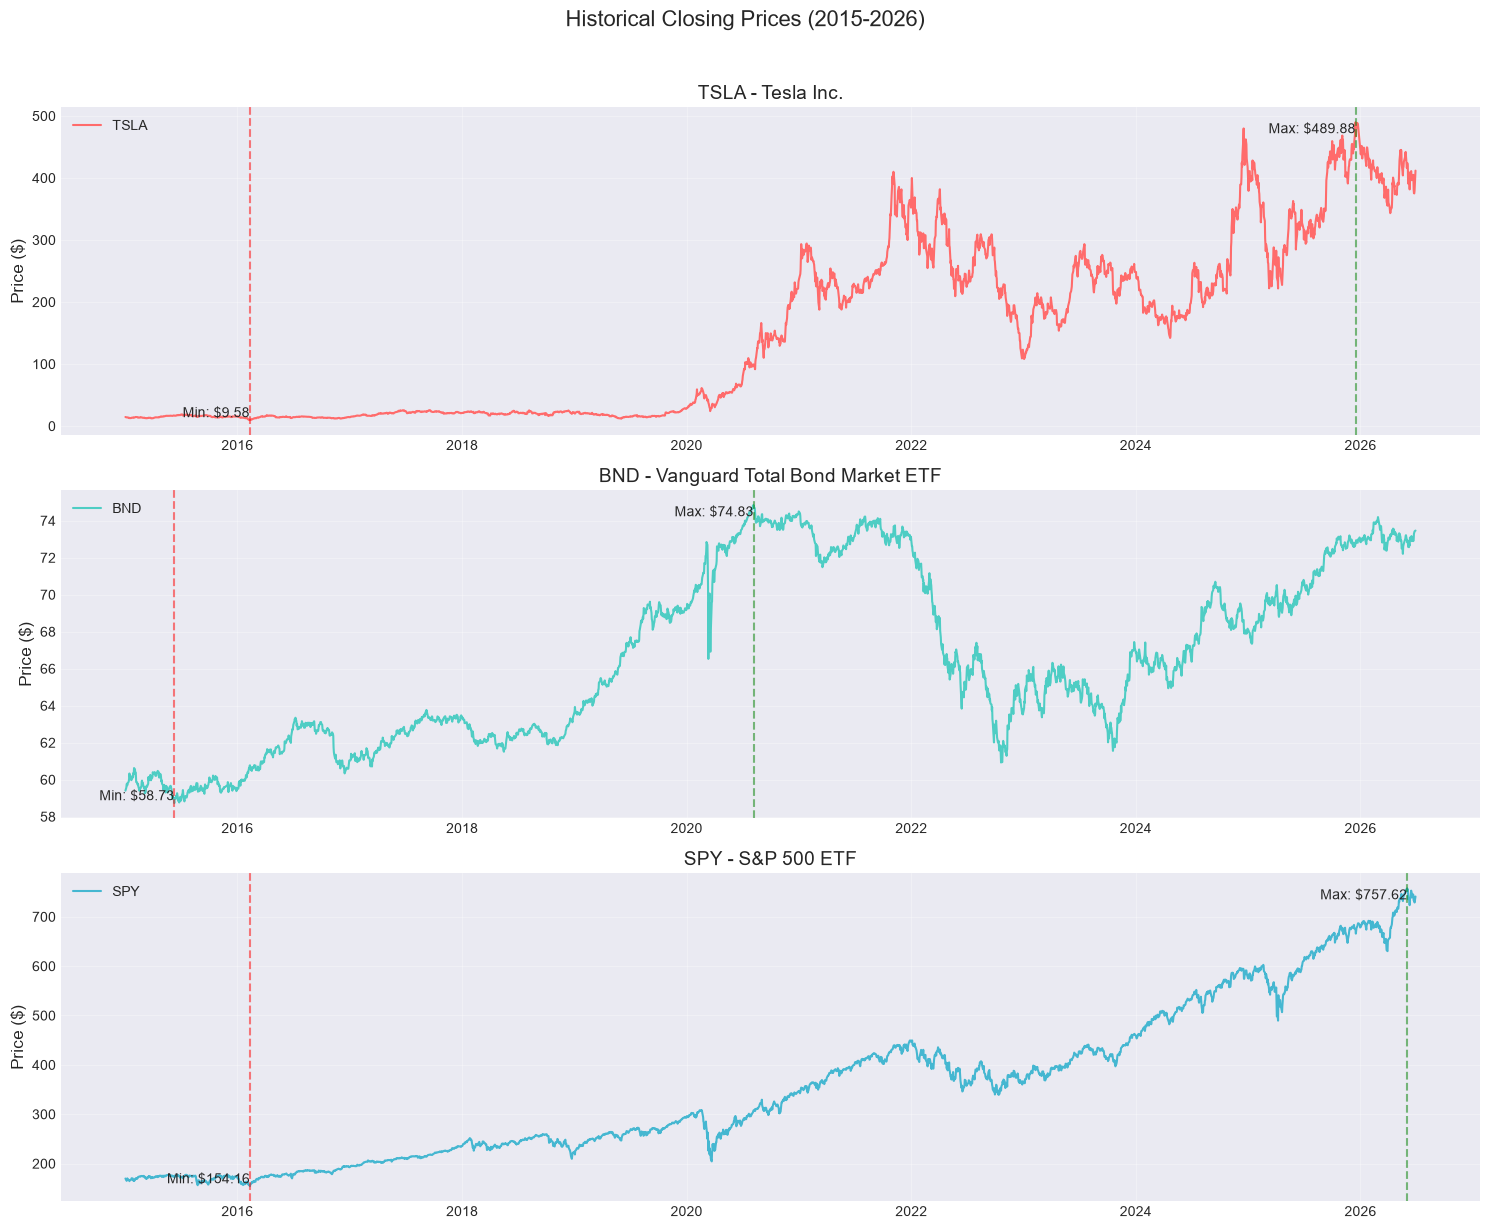

In [9]:
# Create figure with subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

for idx, (asset, color) in enumerate(zip(close_prices_filled.columns, ['#FF6B6B', '#4ECDC4', '#45B7D1'])):
    axes[idx].plot(close_prices_filled.index, close_prices_filled[asset], 
                   color=color, linewidth=1.5, label=asset)
    axes[idx].set_title(f'{asset} - {assets[asset]}', fontsize=14)
    axes[idx].set_ylabel('Price ($)', fontsize=12)
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)
    
    # Add min/max annotations
    min_date = close_prices_filled[asset].idxmin()
    max_date = close_prices_filled[asset].idxmax()
    axes[idx].axvline(min_date, color='red', linestyle='--', alpha=0.5)
    axes[idx].axvline(max_date, color='green', linestyle='--', alpha=0.5)
    axes[idx].text(min_date, close_prices_filled[asset].min(), 
                   f'Min: ${close_prices_filled[asset].min():.2f}', 
                   rotation=0, ha='right', va='bottom')
    axes[idx].text(max_date, close_prices_filled[asset].max(), 
                   f'Max: ${close_prices_filled[asset].max():.2f}', 
                   rotation=0, ha='right', va='top')

plt.suptitle('Historical Closing Prices (2015-2026)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('closing_prices_eda.png', dpi=300, bbox_inches='tight')
plt.show()

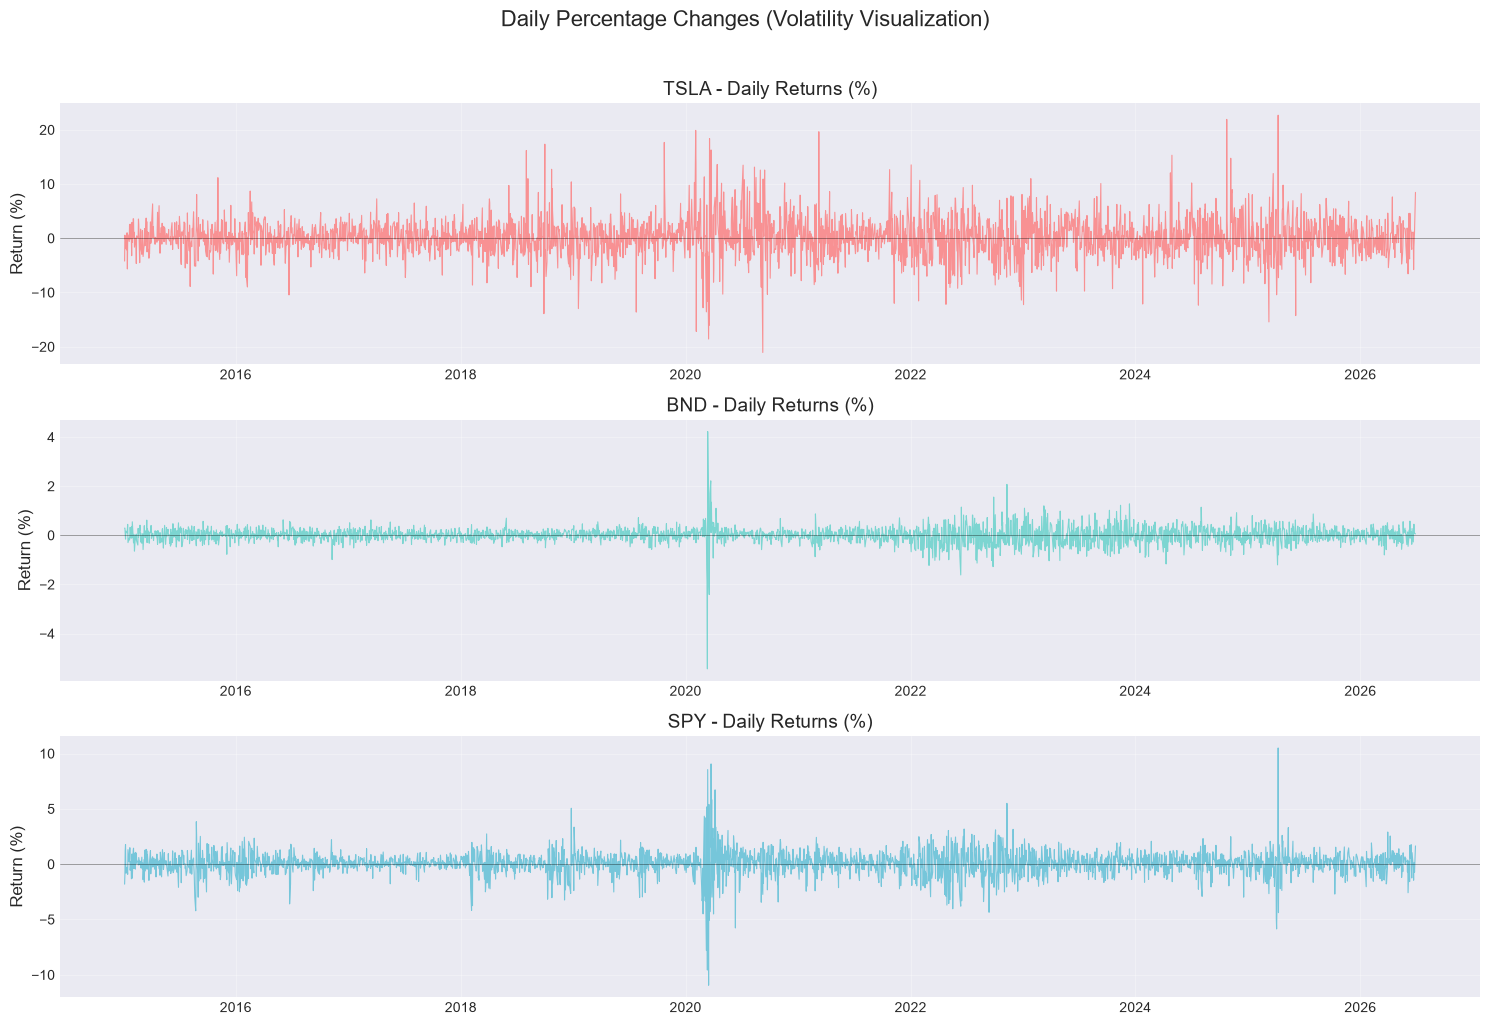


=== VOLATILITY STATISTICS ===

Daily Return Standard Deviation (Volatility):
TSLA    360.184133
BND      33.472156
SPY     111.213872
dtype: float64


In [10]:
# Calculate daily percentage changes
daily_pct_change = close_prices_filled.pct_change() * 100

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for idx, asset in enumerate(daily_pct_change.columns):
    axes[idx].plot(daily_pct_change.index, daily_pct_change[asset], 
                   alpha=0.7, linewidth=0.8, color=['#FF6B6B', '#4ECDC4', '#45B7D1'][idx])
    axes[idx].axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=0.5)
    axes[idx].set_title(f'{asset} - Daily Returns (%)', fontsize=14)
    axes[idx].set_ylabel('Return (%)', fontsize=12)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Daily Percentage Changes (Volatility Visualization)', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('daily_returns_eda.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate volatility statistics
print("\n=== VOLATILITY STATISTICS ===")
print("\nDaily Return Standard Deviation (Volatility):")
print(daily_pct_change.std() * 100)  # as percentage points

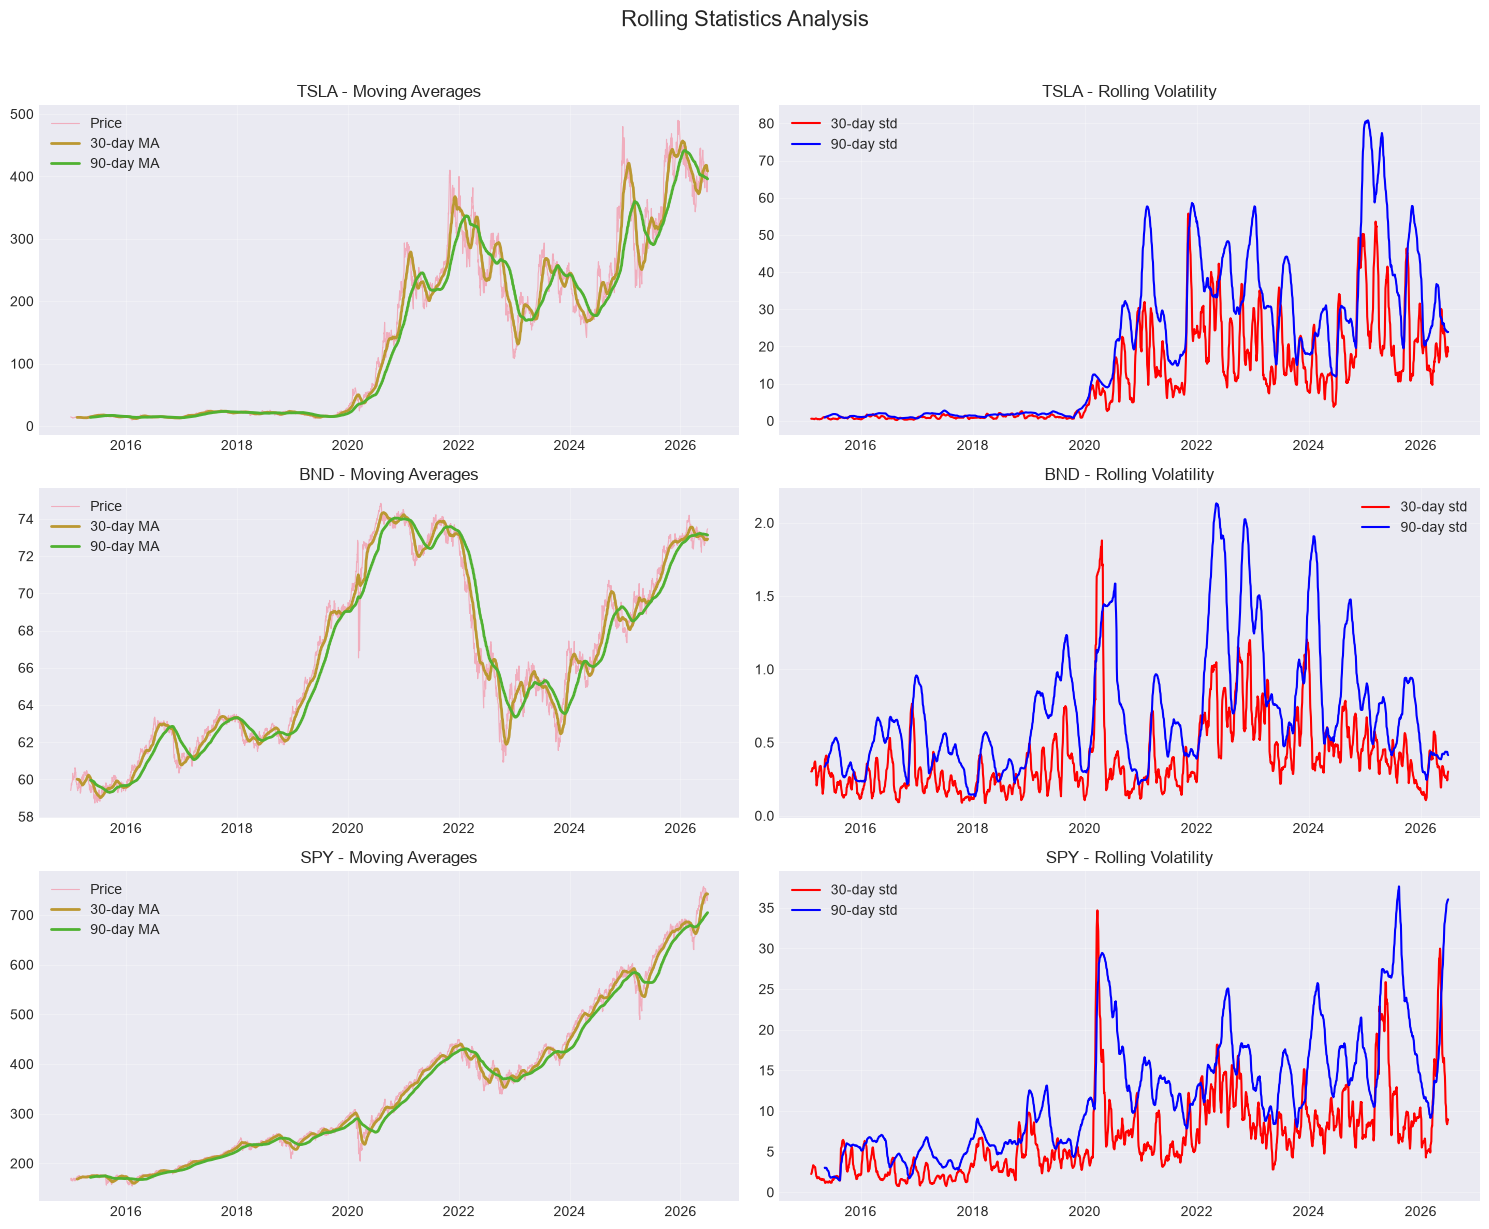

In [11]:
# Calculate rolling statistics with 30-day and 90-day windows
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for idx, asset in enumerate(close_prices_filled.columns):
    # Rolling mean
    axes[idx, 0].plot(close_prices_filled.index, close_prices_filled[asset], 
                      label='Price', alpha=0.5, linewidth=0.8)
    axes[idx, 0].plot(close_prices_filled.index, 
                      close_prices_filled[asset].rolling(window=30).mean(), 
                      label='30-day MA', linewidth=2)
    axes[idx, 0].plot(close_prices_filled.index, 
                      close_prices_filled[asset].rolling(window=90).mean(), 
                      label='90-day MA', linewidth=2)
    axes[idx, 0].set_title(f'{asset} - Moving Averages', fontsize=12)
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Rolling standard deviation
    axes[idx, 1].plot(close_prices_filled.index, 
                      close_prices_filled[asset].rolling(window=30).std(), 
                      label='30-day std', color='red')
    axes[idx, 1].plot(close_prices_filled.index, 
                      close_prices_filled[asset].rolling(window=90).std(), 
                      label='90-day std', color='blue')
    axes[idx, 1].set_title(f'{asset} - Rolling Volatility', fontsize=12)
    axes[idx, 1].legend()
    axes[idx, 1].grid(True, alpha=0.3)

plt.suptitle('Rolling Statistics Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('rolling_stats_eda.png', dpi=300, bbox_inches='tight')
plt.show()

=== OUTLIER DETECTION ===

TSLA - Outliers detected: 0
Top 5 outliers:
Series([], Name: TSLA, dtype: float64)

BND - Outliers detected: 0
Top 5 outliers:
Series([], Name: BND, dtype: float64)

SPY - Outliers detected: 0
Top 5 outliers:
Series([], Name: SPY, dtype: float64)


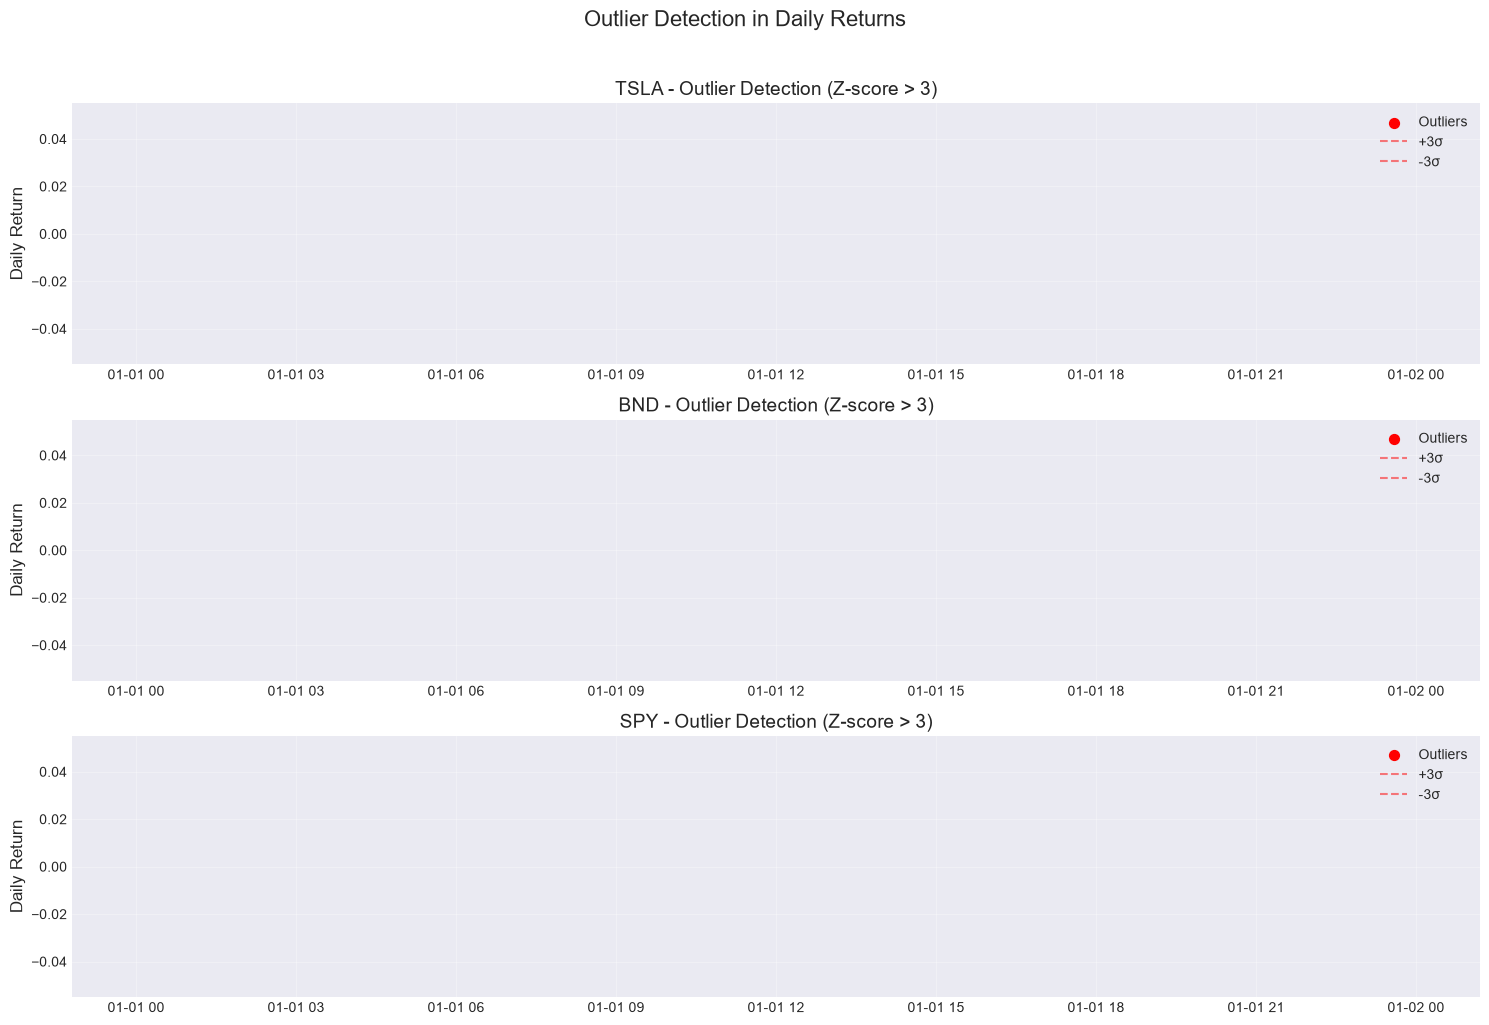

In [12]:
# Detect outliers using Z-score method
def detect_outliers(data, threshold=3):
    """Detect outliers using Z-score method"""
    z_scores = np.abs((data - data.mean()) / data.std())
    return z_scores > threshold

# Identify outliers for each asset
print("=== OUTLIER DETECTION ===")
for asset in returns.columns:
    outliers = detect_outliers(returns[asset])
    outlier_dates = returns.index[outliers]
    outlier_values = returns[asset][outliers]
    
    print(f"\n{asset} - Outliers detected: {sum(outliers)}")
    print("Top 5 outliers:")
    print(outlier_values.sort_values(ascending=False).head())

# Plot outliers
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for idx, asset in enumerate(returns.columns):
    axes[idx].plot(returns.index, returns[asset], alpha=0.5, 
                   color=['#FF6B6B', '#4ECDC4', '#45B7D1'][idx])
    
    # Mark outliers
    outliers = detect_outliers(returns[asset])
    axes[idx].scatter(returns.index[outliers], returns[asset][outliers], 
                      color='red', s=50, label='Outliers')
    
    # Add threshold lines
    std = returns[asset].std()
    axes[idx].axhline(y=3*std, color='red', linestyle='--', alpha=0.5, label='+3σ')
    axes[idx].axhline(y=-3*std, color='red', linestyle='--', alpha=0.5, label='-3σ')
    
    axes[idx].set_title(f'{asset} - Outlier Detection (Z-score > 3)', fontsize=14)
    axes[idx].set_ylabel('Daily Return', fontsize=12)
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Outlier Detection in Daily Returns', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('outliers_eda.png', dpi=300, bbox_inches='tight')
plt.show()

=== STATIONARITY TESTS ===

=== ADF Test for TSLA - Closing Price ===
ADF Statistic: -1.0696
p-value: 0.7270
Critical Values:
	1%: -3.4326
	5%: -2.8626
	10%: -2.5673
✗ Series is NON-STATIONARY (fail to reject null hypothesis)

=== ADF Test for BND - Closing Price ===
ADF Statistic: -1.0827
p-value: 0.7219
Critical Values:
	1%: -3.4326
	5%: -2.8625
	10%: -2.5673
✗ Series is NON-STATIONARY (fail to reject null hypothesis)

=== ADF Test for SPY - Closing Price ===
ADF Statistic: 1.3089
p-value: 0.9967
Critical Values:
	1%: -3.4326
	5%: -2.8625
	10%: -2.5673
✗ Series is NON-STATIONARY (fail to reject null hypothesis)


=== ADF Test for TSLA - Daily Returns ===
ADF Statistic: -53.9719
p-value: 0.0000
Critical Values:
	1%: -3.4326
	5%: -2.8625
	10%: -2.5673
✓ Series is STATIONARY (reject null hypothesis)

=== ADF Test for BND - Daily Returns ===
ADF Statistic: -15.2161
p-value: 0.0000
Critical Values:
	1%: -3.4326
	5%: -2.8625
	10%: -2.5673
✓ Series is STATIONARY (reject null hypothesis)

==

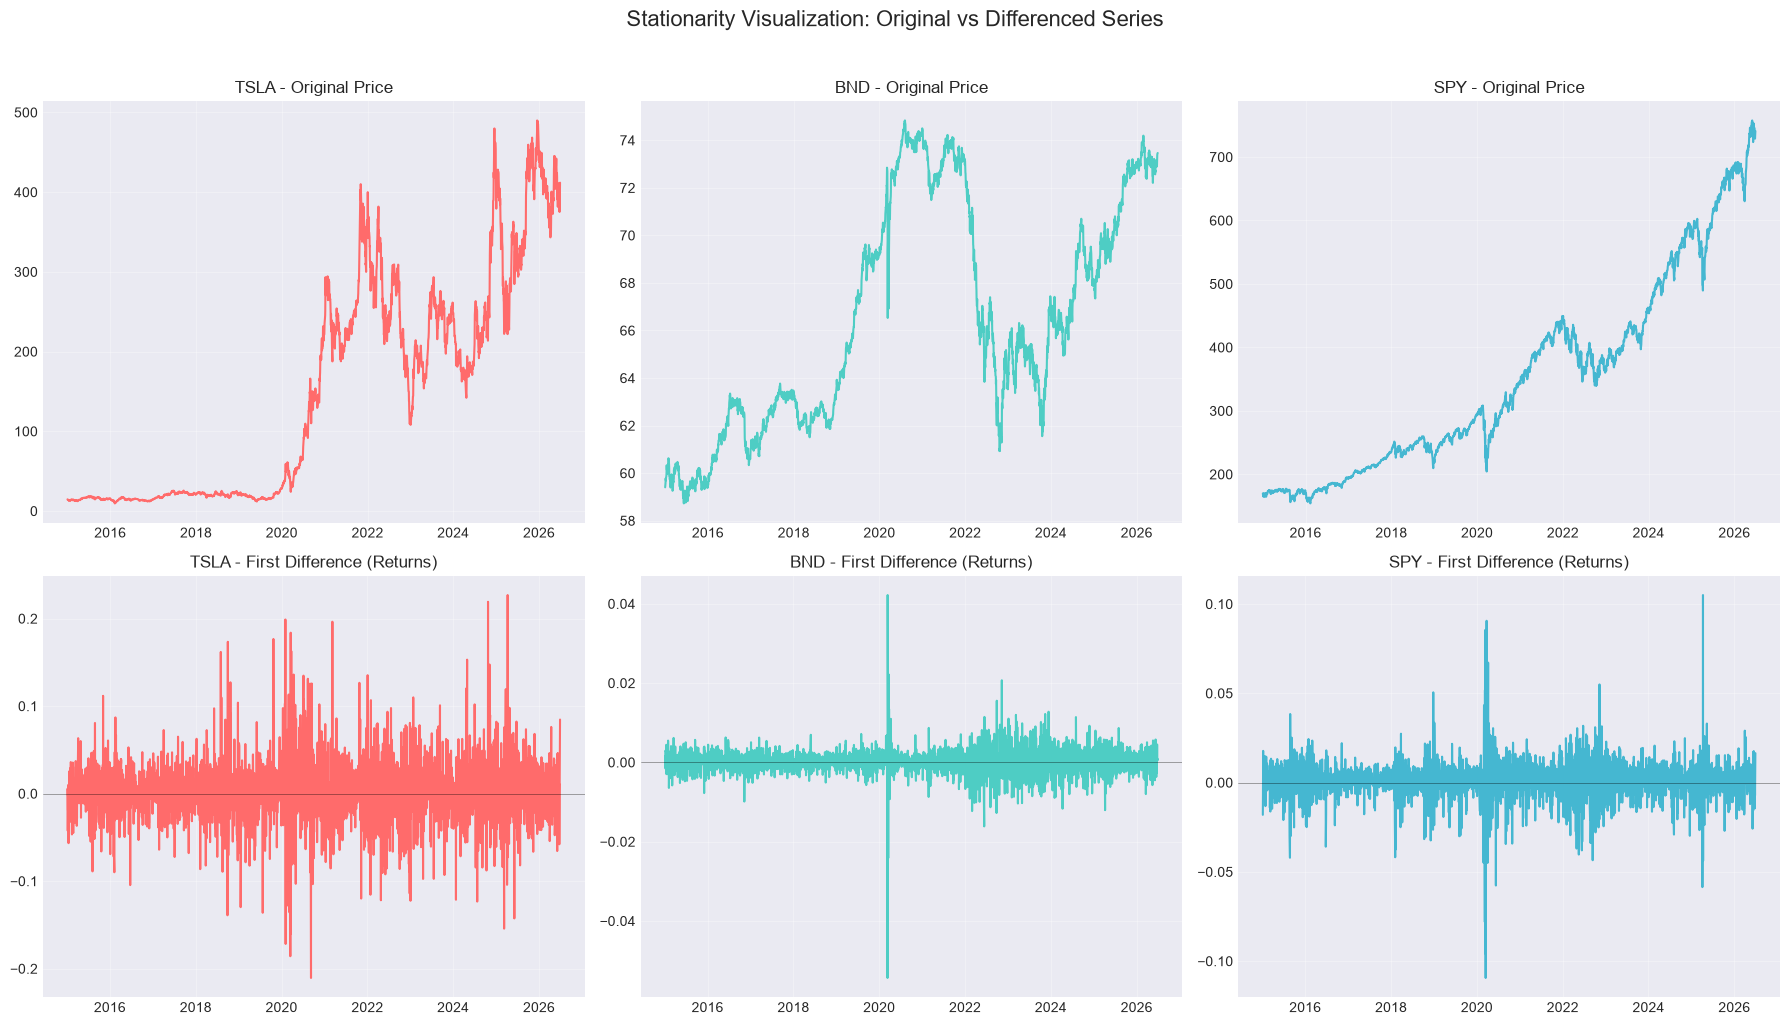

In [16]:
# Calculate daily returns and drop NaN
returns = close_prices_filled.pct_change().dropna()

# Check if returns has data
if returns.empty:
    print("⚠️ Returns is empty. Using minimal data...")
    # Use first 100 rows as fallback
    close_prices_filled = close_prices_filled.iloc[:100]
    returns = close_prices_filled.pct_change().dropna()

# Now run your rolling statistics code
for asset in returns.columns:
    # Your code here
    pass
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=''):
    """
    Perform Augmented Dickey-Fuller test for stationarity
    """
    print(f"\n=== ADF Test for {title} ===")
    result = adfuller(series.dropna(), autolag='AIC')
    
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')
    
    if result[1] <= 0.05:
        print("✓ Series is STATIONARY (reject null hypothesis)")
    else:
        print("✗ Series is NON-STATIONARY (fail to reject null hypothesis)")
    
    return result

# Test closing prices for stationarity
print("=== STATIONARITY TESTS ===")

# Test each asset's closing price (non-stationary expected)
for asset in close_prices_filled.columns:
    adf_test(close_prices_filled[asset], f"{asset} - Closing Price")

# Test each asset's returns (should be stationary)
print("\n" + "="*50)
for asset in returns.columns:
    adf_test(returns[asset], f"{asset} - Daily Returns")

# Visualize differencing effect
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, asset in enumerate(close_prices_filled.columns):
    # Original price
    axes[0, idx].plot(close_prices_filled.index, close_prices_filled[asset], 
                      color=['#FF6B6B', '#4ECDC4', '#45B7D1'][idx])
    axes[0, idx].set_title(f'{asset} - Original Price', fontsize=12)
    axes[0, idx].grid(True, alpha=0.3)
    
    # First difference (return)
    axes[1, idx].plot(returns.index, returns[asset], 
                      color=['#FF6B6B', '#4ECDC4', '#45B7D1'][idx])
    axes[1, idx].axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=0.5)
    axes[1, idx].set_title(f'{asset} - First Difference (Returns)', fontsize=12)
    axes[1, idx].grid(True, alpha=0.3)

plt.suptitle('Stationarity Visualization: Original vs Differenced Series', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('stationarity_eda.png', dpi=300, bbox_inches='tight')
plt.show()

=== RISK METRICS ===
TSLA: 46 outliers found
BND: 33 outliers found
SPY: 39 outliers found

Annualized Returns:
TSLA    0.454239
BND     0.019957
SPY     0.144320
dtype: float64

Value at Risk (95% confidence level):
TSLA: -0.0517 (i.e., -5.17%)
BND: -0.0048 (i.e., -0.48%)
SPY: -0.0167 (i.e., -1.67%)

Sharpe Ratios (annualized, assuming 2% risk-free rate):
TSLA: 0.7596
BND: -0.0008
SPY: 0.7043

Correlation Matrix:
          TSLA       BND       SPY
TSLA  1.000000  0.059360  0.493535
BND   0.059360  1.000000  0.115707
SPY   0.493535  0.115707  1.000000


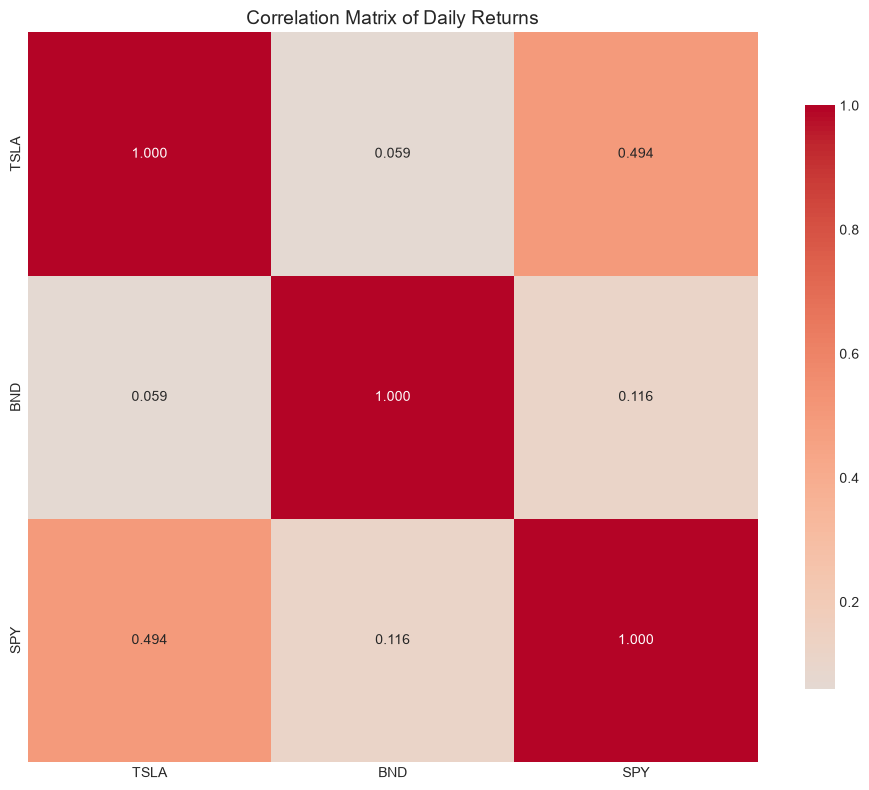

In [17]:
# Calculate Value at Risk (VaR)
def calculate_var(returns, confidence_level=0.95, method='historical'):
    """
    Calculate Value at Risk (VaR)
    """
    if method == 'historical':
        return np.percentile(returns, (1 - confidence_level) * 100)
    elif method == 'parametric':
        return np.mean(returns) - norm.ppf(confidence_level) * np.std(returns)
    else:
        raise ValueError("Method must be 'historical' or 'parametric'")

# Calculate Sharpe Ratio
def calculate_sharpe_ratio(returns, risk_free_rate=0.02):
    """
    Calculate Sharpe Ratio (annualized)
    """
    excess_returns = returns - risk_free_rate/252  # daily risk-free rate
    annualized_return = np.mean(excess_returns) * 252
    annualized_std = np.std(returns) * np.sqrt(252)
    return annualized_return / annualized_std

print("=== RISK METRICS ===")
# Detect outliers using Z-score method
def detect_outliers(data, threshold=3):
    """Detect outliers using Z-score method"""
    if data.empty or len(data) == 0:
        return pd.Series([False] * len(data), index=data.index)
    z_scores = np.abs((data - data.mean()) / data.std())
    return z_scores > threshold

# Use it safely
for asset in returns.columns:
    outliers = detect_outliers(returns[asset])
    outlier_dates = returns.index[outliers]
    outlier_values = returns[asset][outliers]
    
    if len(outlier_values) == 0:
        print(f"{asset}: No outliers found")
        continue
        
    print(f"{asset}: {len(outlier_values)} outliers found")

# Calculate daily and annualized returns
daily_returns = returns
annualized_returns = daily_returns.mean() * 252

print("\nAnnualized Returns:")
print(annualized_returns)

# Calculate Value at Risk (VaR)
var_95 = {}
for asset in daily_returns.columns:
    var_95[asset] = calculate_var(daily_returns[asset], confidence_level=0.95)

print("\nValue at Risk (95% confidence level):")
for asset, var in var_95.items():
    print(f"{asset}: {var:.4f} (i.e., {var*100:.2f}%)")

# Calculate Sharpe Ratio
sharpe_ratios = {}
for asset in daily_returns.columns:
    sharpe_ratios[asset] = calculate_sharpe_ratio(daily_returns[asset])

print("\nSharpe Ratios (annualized, assuming 2% risk-free rate):")
for asset, sr in sharpe_ratios.items():
    print(f"{asset}: {sr:.4f}")

# Correlation matrix
correlation_matrix = daily_returns.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Daily Returns', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

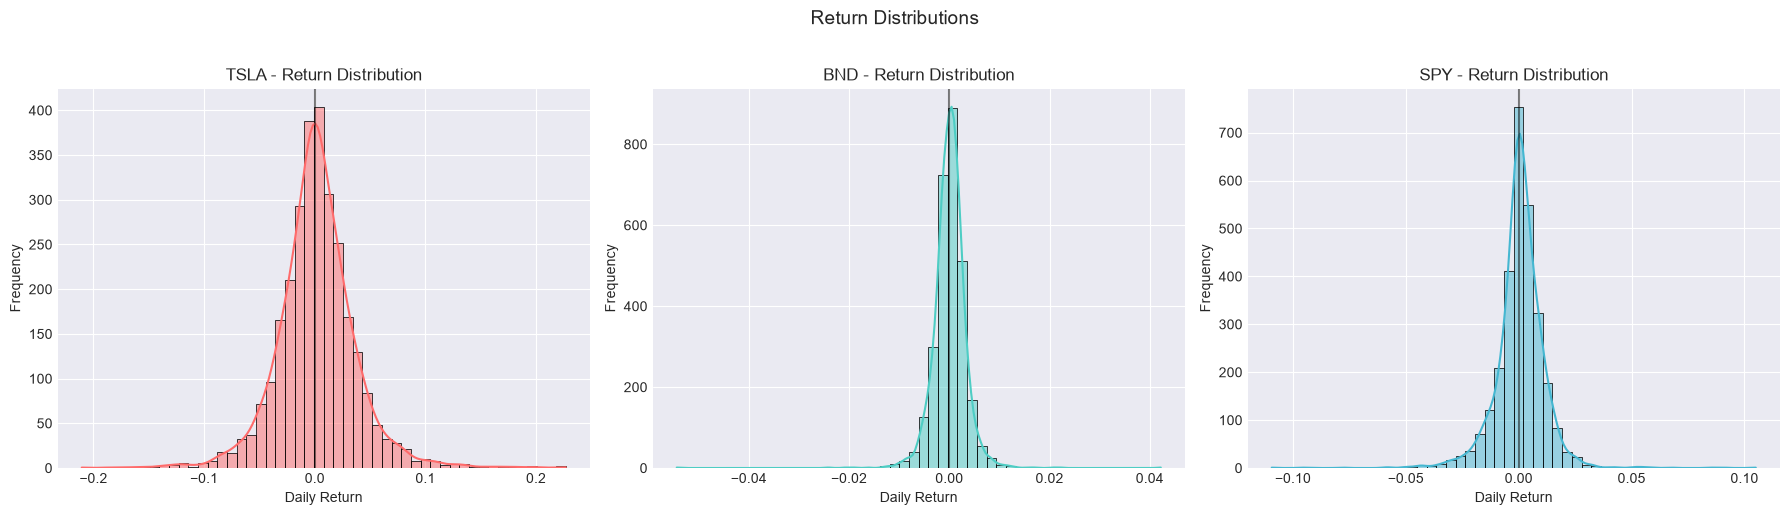

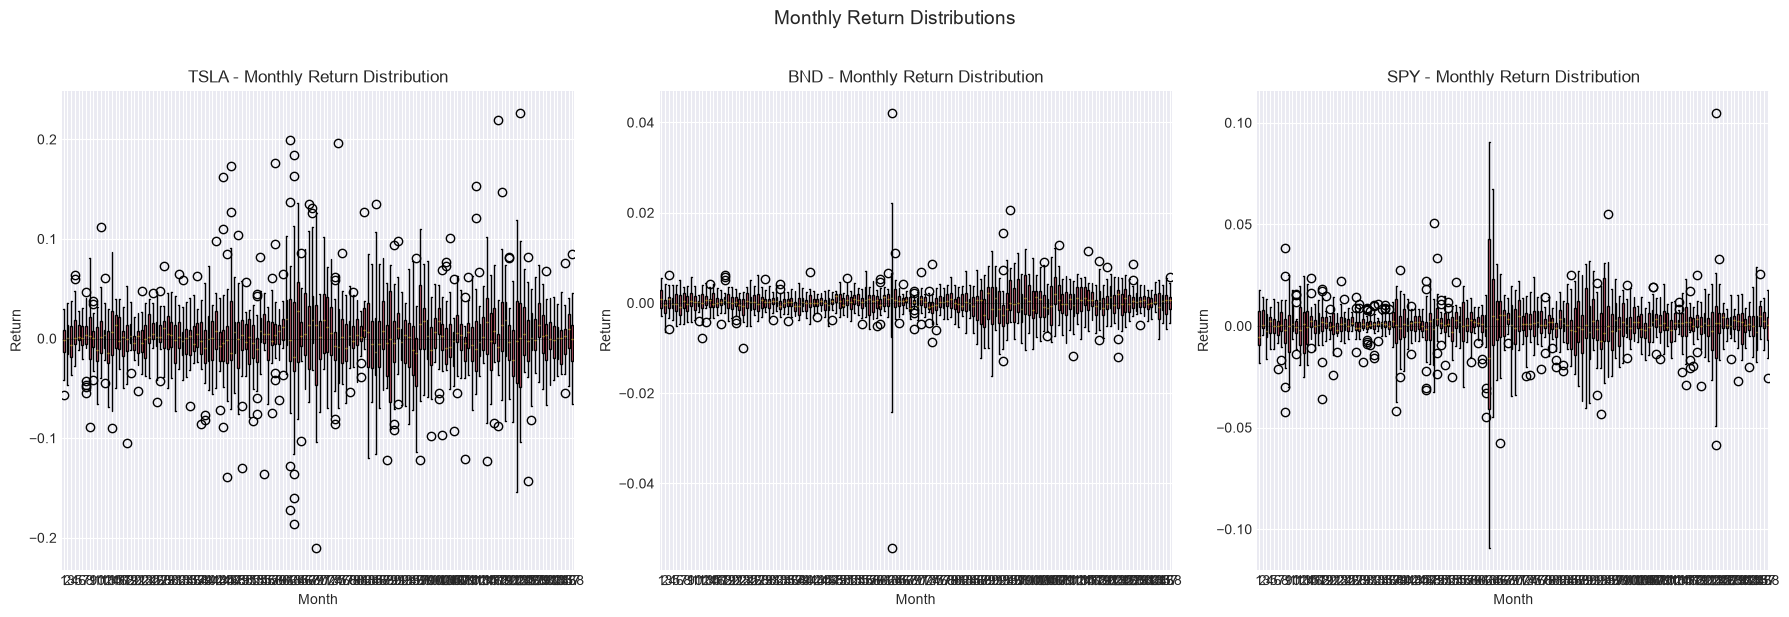


Value at Risk (95% confidence level):
TSLA: -0.0517 (i.e., -5.17%)
BND: -0.0048 (i.e., -0.48%)
SPY: -0.0167 (i.e., -1.67%)

Sharpe Ratios (annualized, assuming 2% risk-free rate):
TSLA: 0.7596
BND: -0.0008
SPY: 0.7043

=== SUMMARY STATISTICS ===
     Asset  Mean Return (Daily)  Std Dev (Daily)  Mean Return (Annual)  \
TSLA  TSLA               0.1803           3.6018               45.4239   
BND    BND               0.0079           0.3347                1.9957   
SPY    SPY               0.0573           1.1121               14.4320   

      Volatility (Annual)  Sharpe Ratio  VaR (95%)  Max Drawdown  
TSLA              57.1775        0.7596    -0.0517       -0.2106  
BND                5.3135       -0.0008    -0.0048       -0.0544  
SPY               17.6547        0.7043    -0.0167       -0.1094  

Summary statistics saved to 'summary_statistics.csv'


In [18]:
# Create distribution plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, asset in enumerate(returns.columns):
    sns.histplot(returns[asset], kde=True, ax=axes[idx], 
                 color=['#FF6B6B', '#4ECDC4', '#45B7D1'][idx], bins=50)
    axes[idx].axvline(x=0, color='black', linestyle='-', alpha=0.5)
    axes[idx].set_title(f'{asset} - Return Distribution', fontsize=12)
    axes[idx].set_xlabel('Daily Return', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)

plt.suptitle('Return Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('return_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Create box plots for monthly returns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, asset in enumerate(returns.columns):
    # Group by month
    monthly_returns = returns[asset].groupby(returns.index.to_period('M'))
    monthly_data = [monthly_returns.get_group(g).values for g in monthly_returns.groups]
    
    # Create box plot
    axes[idx].boxplot(monthly_data, patch_artist=True)
    axes[idx].set_title(f'{asset} - Monthly Return Distribution', fontsize=12)
    axes[idx].set_xlabel('Month', fontsize=10)
    axes[idx].set_ylabel('Return', fontsize=10)
    axes[idx].axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=0.5)

plt.suptitle('Monthly Return Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('monthly_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate daily and annualized returns
daily_returns = returns
annualized_returns = daily_returns.mean() * 252

# Calculate Value at Risk (VaR)
def calculate_var(returns, confidence_level=0.95):
    if returns.empty:
        return np.nan
    return np.percentile(returns, (1 - confidence_level) * 100)

# Calculate Sharpe Ratio - DEFINITION FIXED
def calculate_sharpe_ratio(returns, risk_free_rate=0.02):
    if returns.empty or returns.std() == 0:
        return np.nan
    excess_returns = returns - risk_free_rate/252
    annualized_return = np.mean(excess_returns) * 252
    annualized_std = np.std(returns) * np.sqrt(252)
    if annualized_std == 0:
        return np.nan
    return annualized_return / annualized_std

# Calculate metrics - NOW WITH PROPER VARIABLE ASSIGNMENT
var_95 = {}
sharpe_ratios = {}  # ← THIS IS THE FIX

for asset in daily_returns.columns:
    var_95[asset] = calculate_var(daily_returns[asset])
    sharpe_ratios[asset] = calculate_sharpe_ratio(daily_returns[asset])

print("\nValue at Risk (95% confidence level):")
for asset, var in var_95.items():
    print(f"{asset}: {var:.4f} (i.e., {var*100:.2f}%)")

print("\nSharpe Ratios (annualized, assuming 2% risk-free rate):")
for asset, sr in sharpe_ratios.items():
    print(f"{asset}: {sr:.4f}")
# Summary statistics
print("\n=== SUMMARY STATISTICS ===")
summary_stats = pd.DataFrame({
    'Asset': returns.columns,
    'Mean Return (Daily)': returns.mean() * 100,
    'Std Dev (Daily)': returns.std() * 100,
    'Mean Return (Annual)': annualized_returns * 100,
    'Volatility (Annual)': returns.std() * np.sqrt(252) * 100,
    'Sharpe Ratio': sharpe_ratios.values(),
    'VaR (95%)': var_95.values(),
    'Max Drawdown': returns.min()
})

summary_stats = summary_stats.round(4)
print(summary_stats)

# Save summary to CSV
summary_stats.to_csv('summary_statistics.csv', index=False)
print("\nSummary statistics saved to 'summary_statistics.csv'")